## Daniel Nachmann

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import np as npest
from scipy.stats import norm

# Problems: Kernel Density Estimation

**Problem 1.** Suppose the data are `[1, 1.75, 2, 3, 3.25, 4]`.

- a. Sketch the empirical cumulative distribution function.
- b. Sketch the uniform kernel density estimator for a bandwidth of `h = 0.2`
- c. Compute the Silverman bandwidth for the uniform kernel using `h = 1.84 * SD * n**(-0.2)`.
- d. Sketch the uniform kernel density estimator for the Silverman bandwidth.
- e. How are b and d similar or different?

In [2]:
x = np.array([1, 1.75, 2, 3, 3.25, 4])

Text(0.5, 0, 'x')

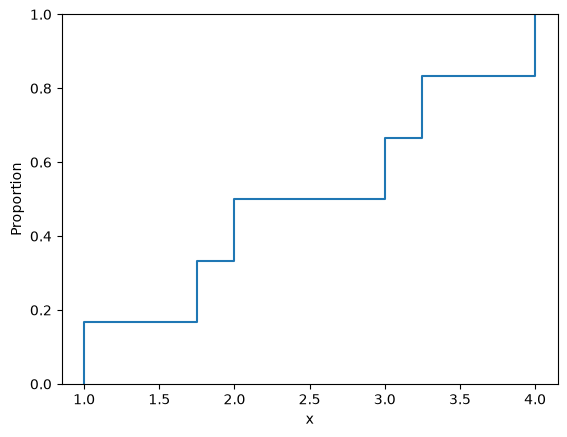

In [ ]:
#a
sns.ecdfplot(x)
plt.xlabel('x')

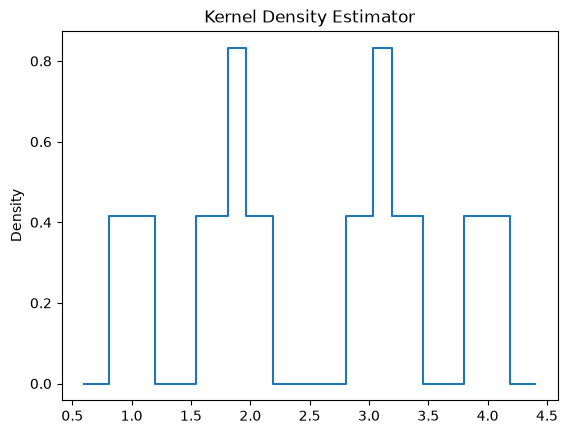

In [11]:
#b 

kde1b = npest.kde(x, kernel_type = 'uniform')

kde1b.fit(h=.2)

kde1b.plot()

In [18]:
#c
bandwidth1c = 1.84 * x.std() * len(x) ** (-0.2) 
bandwidth1c

np.float64(1.2991670409500977)

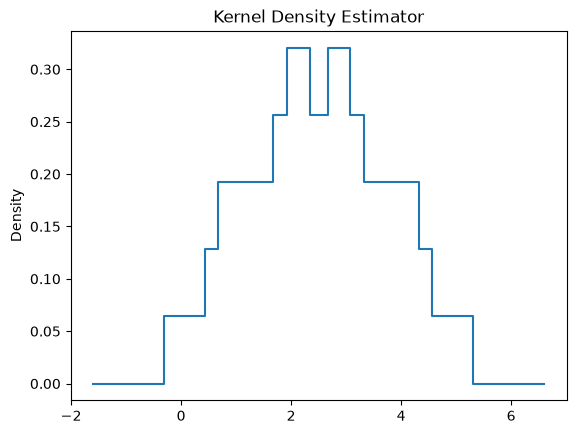

In [ ]:
#d

kde1d = npest.kde(x, kernel_type = 'uniform')

kde1d.fit(h = bandwidth1c)

kde1d.plot()

e. The plots in b and d differ only in their bandwidths. A smaller bandwidth like the one in part b means the plot will follow the observed data more closely. As a result, the plot will not appear as smooth and will have many peaks and valleys. The Silverman bandwidth is greater than the one in part b, and the distribution appears to be smoother.

**Problem 2.** Suppose the data `X = [-1, -0.5, 0, 0.5, 1]` were drawn from a standard Normal distribution.

- a. Using the uniform kernel with `h = 0.6`, compute the realized KDE at `x = 0`, `f_hat_h(0)`, directly from these five numbers.
- b. Now compute `E[f_hat_h(0)]` at the same `h = 0.6`.
- c. Calculate the true density at `x=0`, using the Normal distribution.
- d. Are b and c equal? What does this mean about bias? (Keep in mind, truly proving anything about bias would require us to compare `E[f_hat_h]` to the Normal distribution for all x; calculating this at one point is only an indication of what is going on that you can extrapolate from.)
- e. Recompute `E[f_hat_h(0)]` from (b) at a much smaller bandwidth, `h = 0.1`. What happens to the gap between `E[f_hat_h(0)]` and `f(0)` as `h` shrinks?
- f. Is `f_hat_h` a consistent estimator? Explain your reasoning.
- g. What are the main considerations in choosing a bandwidth value `h`?

In [11]:
x = np.array([-1, -.5, 0, .5, 1])
h = .6

In [22]:
#a
f_hat_2a = 3 / (2 * 5 * 0.6)
f_hat_2a

0.5

In [9]:
#b
x = 0
f_hat_2b = ((norm.cdf(x + h)) - (norm.cdf(x - h))) / (2*h)
f_hat_2b

np.float64(0.3762448037498774)

In [10]:
#c

density_2c = (1 / (np.sqrt(2 * np.pi))) * np.e**((-1/2) * ((0-0) / 1)**2)

density_2c

np.float64(0.3989422804014327)

d. The results for b and c are not equal, as the true density is slightly higher than our estimation. Because our bandwidth, 0.6, is an estimation between -0.6 and 0.6, it is not as precise as the exact density.

In [ ]:
#e 

x = 0
h = .1
f_hat_2e = ((norm.cdf(x + h)) - (norm.cdf(x - h))) / (2*h)
f_hat_2e

#As h shrinks, the gap between E[f_hat_h_(0)] and f(0) shrinks.

np.float64(0.3982783727702899)

f. Yes, f_hat_h is a consistent estimator as long as h approaches 0 as n approaches infinity. If n increases, variance will decrease. Likewise, as h decreases, the bias also decreases, causing f_hat_h to converge to the true density. 

g. The main considerations in choosing a bandwidth is balancing bias and variance. If the bandwidth is too small to 0, f_hat_h will be too accurate, leading to higher variance. Likewise, if h is too large, there will be a higher bias but lower variance.

**Problem 3.** Suppose the data are `X = [5, 7, 7, 8, 10]`, and fix the bandwidth at `h = 1.5` for both kernels below.

- a. Compute the uniform-kernel KDE, `f_hat_h(x)`, at `x = 6.0`, `x = 6.5`, `x = 7.0`, `x = 8.0`, and `x = 8.5`.
- b. Compute the Gaussian-kernel KDE at the same five values of `x`, using the same `h = 1.5`.
- c. Your part (a) values should jump abruptly between some of these five points, while your part (b) values should change smoothly. Identify where the biggest jump in (a) happens, and explain in terms of the two kernel *shapes* -- not just "one is smoother" -- why that jump exists in the uniform case but not the Gaussian case.
- d. Why might you prefer one kernel over the other in practice?

In [22]:
(5+7+7+8+10) / 5

7.4

In [16]:
x = np.array([5, 7, 7, 8, 10])
h = 1.5

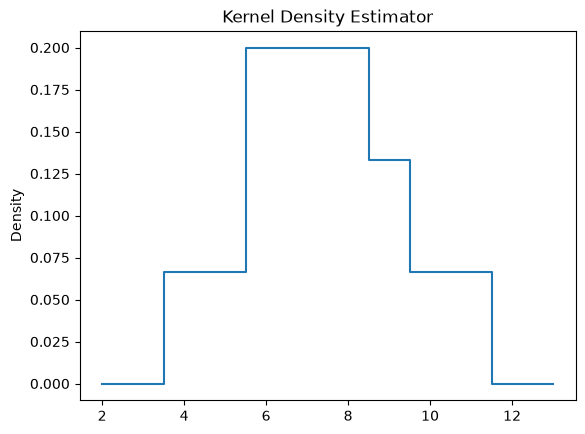

In [ ]:
#a
f_hat_3a = npest.kde(x, kernel_type = 'uniform')

f_hat_3a.fit(h = h)

f_hat_3a.plot()

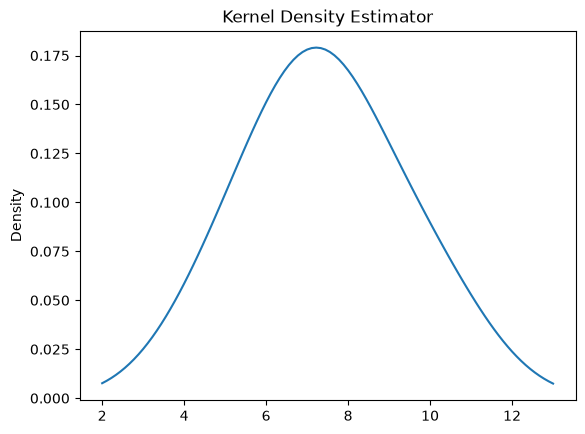

In [ ]:
#b
f_hat_3b = npest.kde(x, kernel_type = 'gaussian')

f_hat_3b.fit(h = h)

f_hat_3b.plot()

c. The biggest jump in (a) happens at around x = 6. The jump exists in the uniform estimation because each point within the range of -h to h is given an equal density. The Gaussian estimation smooths the distribution out by continuously decreasing density as x changes, rather than a flat change that causes abrupt jumps. 

d. A Gaussian kernel is more useful for visualizing continuous data because the smooth curve illustrates how the desnity increases and decreases as the value of x changes. A uniform kernel can be used for data that is always 0 outside of certain thresholds, and the values between these thresholds are equally distributed.

**Problem 4.** Load `./data/heart_failure_clinical_records_dataset.csv`.

- a. Plot a
-  kernel density estimate of `ejection_fraction`.
- b. Use Pandas' `df.sample(frac=1.0, replace=True)` to resample the data 15 times with replacement, plotting the kernel density estimtes for each sample.
- c. For what values of `ejection_fraction` is the original plot reliable? For which values is there noticeable variation in your plots of the resampled data?

In [23]:
df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')


<Axes: xlabel='ejection_fraction', ylabel='Density'>

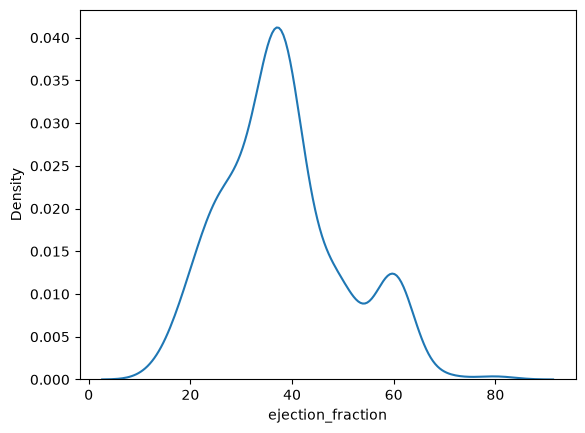

In [24]:
#a 

sns.kdeplot(df['ejection_fraction'])

Text(0.5, 0, 'Ejection Fraction')

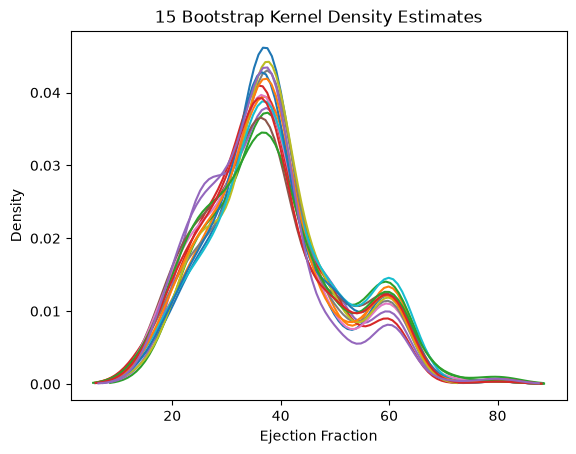

In [38]:
#b
for i in range(15):
    sample_4b = df.sample(frac = 1.0, replace = True)
    x_4b = sample_4b['ejection_fraction'].values
    kde_4b = npest.kde(x_4b, kernel_type = 'gaussian')
    kde_4b.fit()
    kde_4b.plot()

plt.title('15 Bootstrap Kernel Density Estimates')
plt.xlabel('Ejection Fraction')

c. The original KDE appears to be reliable for all values of ejection_fraction apart from around 35-40. At the peak, the original plot appears to be too dense compared to the 14 others, and is less reliable. There is noticable variation around the local maxima and minima, at around 50-60.